In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported")

Libraries imported ✅


In [9]:
df = pd.read_csv(
    '../data/raw/Turbine_Data_Kelmarsh_1_2020-01-01_-_2021-01-01_228.csv',
    skiprows=9,
    index_col=0,
    parse_dates=True
)

df.index.name = 'timestamp'
df.index = pd.to_datetime(df.index)

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")

Shape: (52704, 298)
Date range: 2020-01-01 00:00:00 → 2020-12-31 23:50:00


In [ ]:
cols = {
    'Wind speed (m/s)': 'wind_speed',
    'Wind direction (°)': 'wind_dir',
    'Power (kW)': 'power',
    'Rotor speed (RPM)': 'rotor_rpm',
    'Nacelle position (°)': 'nacelle_pos',
    'Generator bearing front temperature (°C)': 'gen_bearing_front_temp',
    'Generator bearing rear temperature (°C)': 'gen_bearing_rear_temp',
    'Gear oil temperature (°C)': 'gear_oil_temp',
    'Blade angle (pitch position) A (°)': 'pitch_angle',
}

df_core = df[list(cols.keys())].rename(columns=cols)
df_core.head(3)

['wind_speed', 'wind_dir', 'power', 'rotor_rpm', 'nacelle_pos', 'gen_bearing_front_temp', 'gen_bearing_rear_temp', 'gear_oil_temp', 'pitch_angle']


,wind_speed,wind_dir,power,rotor_rpm,nacelle_pos,gen_bearing_front_temp,gen_bearing_rear_temp,gear_oil_temp,pitch_angle
timestamp,,,,,,,,,
2020-01-01 00:00:00,3.887291,116.839462,150.984141,8.449412,97.146416,38.2775,36.752500,56.972500,0.049498
2020-01-01 00:10:00,3.848941,115.659361,130.414782,8.345387,97.146416,39.1450,37.037499,56.695001,0.074499
2020-01-01 00:20:00,4.043625,116.646515,146.401656,8.497044,100.748278,39.8975,37.347500,56.640000,0.074499


In [12]:
print("=== NaN count ===")
print(df_core.isna().sum())

print("\n=== Basic stats ===")
df_core.describe().round(2)

=== NaN count ===
wind_speed                468
wind_dir                  468
power                     468
rotor_rpm                 468
nacelle_pos               468
gen_bearing_front_temp    468
gen_bearing_rear_temp     468
gear_oil_temp             722
pitch_angle               722
dtype: int64

=== Basic stats ===


,wind_speed,wind_dir,power,rotor_rpm,nacelle_pos,gen_bearing_front_temp,gen_bearing_rear_temp,gear_oil_temp,pitch_angle
count,52236.00,52236.00,52236.00,52236.00,52236.00,52236.00,52236.00,51982.00,51982.00
mean,6.52,197.94,716.47,10.77,197.88,38.88,41.18,52.76,6.38
std,3.01,91.14,680.55,4.23,91.30,5.96,5.92,6.46,16.77
min,0.26,0.01,-16.49,0.00,0.03,8.62,7.10,10.20,0.00
25%,4.31,142.19,133.57,8.36,144.34,35.51,38.45,50.81,0.00
50%,6.23,217.53,483.31,11.43,217.88,40.14,40.86,53.90,0.06
75%,8.31,258.12,1194.31,14.64,258.49,43.19,43.66,56.84,1.55
max,22.42,359.96,2078.53,15.34,359.99,64.91,74.32,60.89,92.55


In [15]:
# Drop NaNs
df_clean = df_core.dropna()

# Remove rows where turbine is not producing (idling, shutdown)
df_clean = df_clean[df_clean['power'] > 0]
df_clean = df_clean[df_clean['rotor_rpm'] > 1]

print(f"Rows after cleaning: {len(df_clean)}")
print(f"Rows removed: {len(df_core) - len(df_clean)}")
print(f"Data retained: {len(df_clean)/len(df_core)*100:.1f}%")

Rows after cleaning: 46694
Rows removed: 6010
Data retained: 88.6%


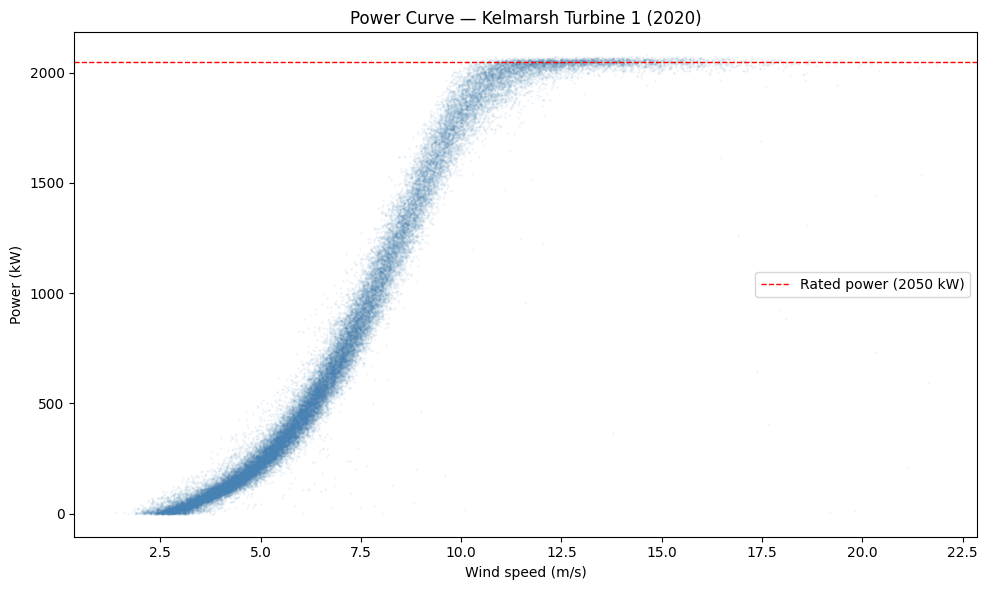

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_clean['wind_speed'], df_clean['power'], 
           alpha=0.05, s=1, color='steelblue')
ax.axhline(2050, color='red', linestyle='--', linewidth=1, label='Rated power (2050 kW)')
ax.set_xlabel('Wind speed (m/s)')
ax.set_ylabel('Power (kW)')
ax.set_title('Power Curve — Kelmarsh Turbine 1 (2020)')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/plots/01_power_curve.png', dpi=150, bbox_inches='tight')
plt.show()

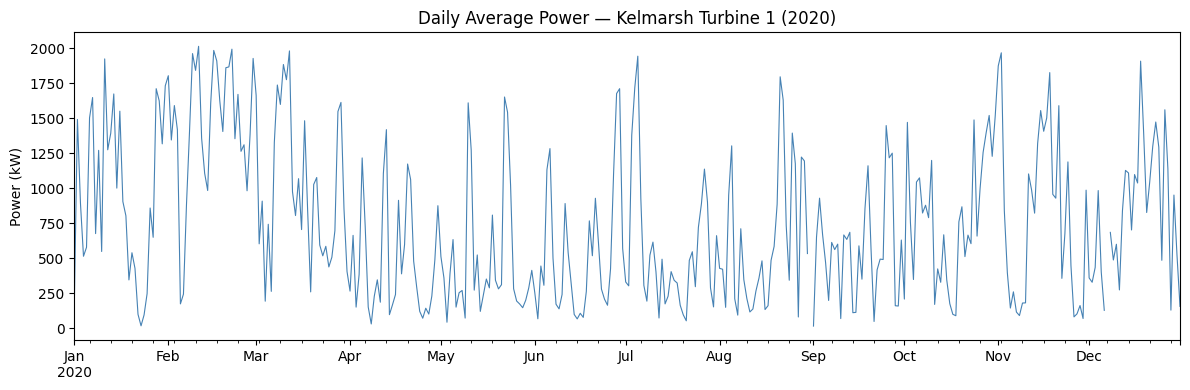

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

df_clean['power'].resample('1D').mean().plot(ax=ax, color='steelblue', linewidth=0.8)

ax.set_title('Daily Average Power — Kelmarsh Turbine 1 (2020)')
ax.set_ylabel('Power (kW)')
ax.set_xlabel('')

plt.tight_layout()
plt.savefig('../outputs/plots/02_power_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

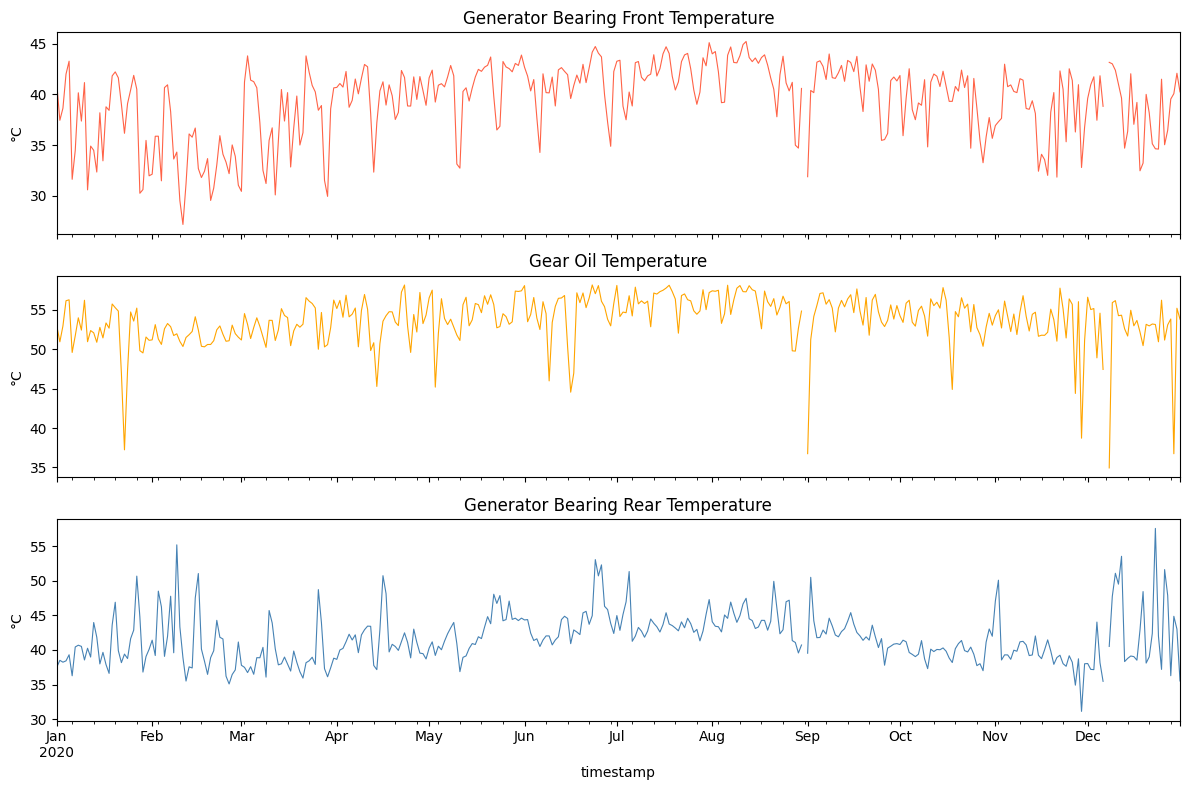

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

df_clean['gen_bearing_front_temp'].resample('1D').mean().plot(
    ax=axes[0], color='tomato', linewidth=0.8)
axes[0].set_ylabel('°C')
axes[0].set_title('Generator Bearing Front Temperature')

df_clean['gear_oil_temp'].resample('1D').mean().plot(
    ax=axes[1], color='orange', linewidth=0.8)
axes[1].set_ylabel('°C')
axes[1].set_title('Gear Oil Temperature')

df_clean['gen_bearing_rear_temp'].resample('1D').mean().plot(
    ax=axes[2], color='steelblue', linewidth=0.8)
axes[2].set_ylabel('°C')
axes[2].set_title('Generator Bearing Rear Temperature')

plt.tight_layout()
plt.savefig('../outputs/plots/03_temperatures.png', dpi=150, bbox_inches='tight')
plt.show()

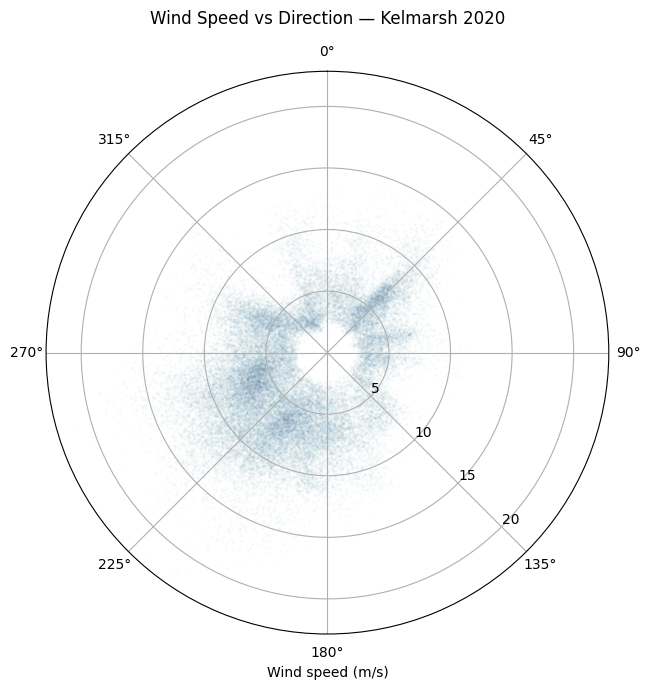

In [ ]:
import numpy as np

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='polar')

# Convert degrees to radians (meteorological: 0°=N, clockwise)
wind_dir_rad = np.deg2rad(df_clean['wind_dir'])

ax.scatter(wind_dir_rad, df_clean['wind_speed'],
           alpha=0.02, s=1, color='steelblue')

# Set North at top, clockwise direction
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

ax.set_title('Wind Speed vs Direction — Kelmarsh 2020', pad=15)
ax.set_xlabel('Wind speed (m/s)')
ax.set_rlabel_position(135)

plt.tight_layout()
plt.savefig('../outputs/plots/04_wind_rose.png', dpi=150, bbox_inches='tight')
plt.show()

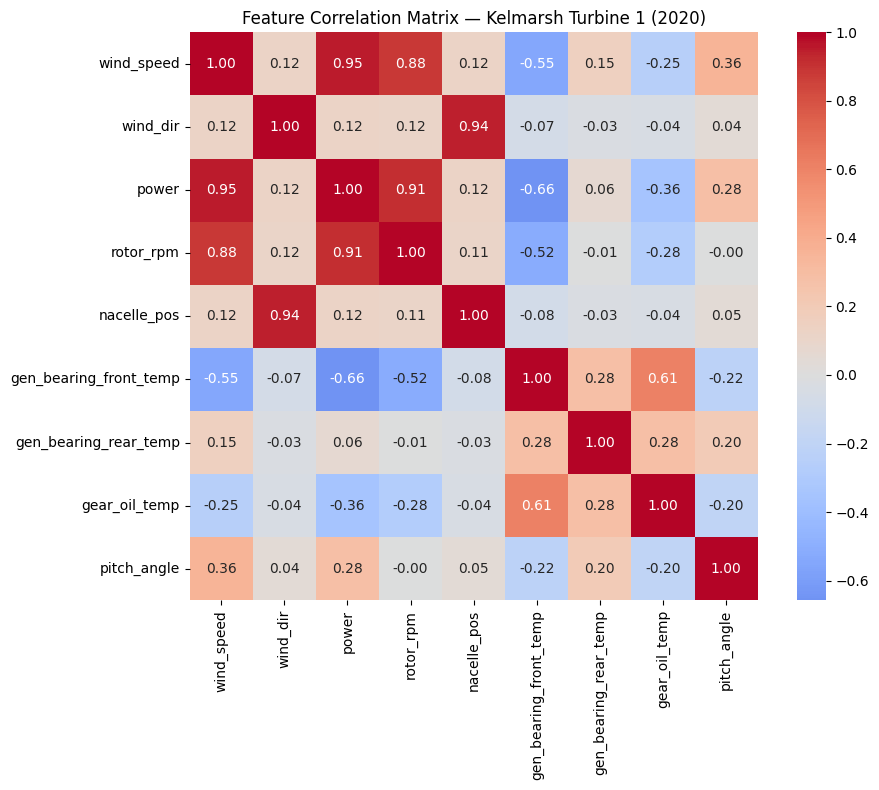

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

corr = df_clean.corr()

sns.heatmap(corr, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True,
            ax=ax)

ax.set_title('Feature Correlation Matrix — Kelmarsh Turbine 1 (2020)')

plt.tight_layout()
plt.savefig('../outputs/plots/05_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
df_clean.to_csv('../data/raw/turbine1_clean.csv')